<a href="https://colab.research.google.com/github/kartikgill/TF2-Keras-GAN-Notebooks/blob/main/dcgan/DC-GAN-Celeb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto: Colorización de Imágenes con Autoencoders

### Resumen del Flujo de Trabajo
Este proyecto implementa un **Denoising Autoencoder Convolucional** diseñado para la tarea de síntesis de color. El flujo se divide en:

1.  **Preprocesamiento**: Extracción de imágenes de paisajes, normalización de píxeles (0-1) y conversión del espacio de color de RGB a Escala de Grises para generar los pares de entrenamiento.
2.  **Arquitectura (Encoder)**: Una serie de capas convolucionales que comprimen la imagen de entrada (150x150x1) en un espacio latente de menor resolución pero con mayor profundidad de características.
3.  **Arquitectura (Decoder)**: Utiliza convoluciones transpuestas para reconstruir la resolución espacial original, proyectando las características aprendidas en 3 canales (RGB).
4.  **Entrenamiento**: Minimización del Error Cuadrático Medio (MSE) entre la predicción y la imagen original.
5.  **Evaluación**: Comparación visual en el conjunto de test para validar la capacidad de generalización del modelo.

# Importing Useful Libraries

In [61]:
import tensorflow
print (tensorflow.__version__)

2.20.0


In [62]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm_notebook
%matplotlib inline

# Download and Unzip dataset

In [63]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("utkarshsaxenadn/landscape-recognition-image-dataset-12k-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'landscape-recognition-image-dataset-12k-images' dataset.
Path to dataset files: /kaggle/input/landscape-recognition-image-dataset-12k-images


## 1. Preprocesamiento de Datos
Cargamos las imágenes, las redimensionamos a 150x150 y generamos los conjuntos X (Grises) e Y (RGB).

In [64]:
import glob
import os

def load_and_preprocess_data(dataset_path, num_images=1000):
    """
    Carga imágenes desde el disco, las redimensiona y crea versiones en escala de grises.

    Parámetros:
    - dataset_path: Ruta raíz donde se encuentran las carpetas de imágenes.
    - num_images: Límite de imágenes a procesar para optimizar memoria.

    Retorna:
    - X: Array de imágenes en escala de grises (Entrada).
    - Y: Array de imágenes en color original (Objetivo/Label).
    """
    images_rgb = []
    images_gray = []

    print(f"Explorando: {dataset_path}")

    # Recopilar rutas de archivos de forma recursiva ignorando mayúsculas/minúsculas
    all_files = []
    for ext in ['*.jpg', '*.jpeg', '*.JPG', '*.JPEG']:
        all_files.extend(glob.glob(os.path.join(dataset_path, "**", ext), recursive=True))

    all_files = all_files[:num_images]

    if not all_files:
        print("Contenido del directorio:", os.listdir(dataset_path))
        return np.array([]), np.array([])

    print(f"Se encontraron {len(all_files)} imágenes. Procesando...")

    for img_path in all_files:
        img = cv2.imread(img_path)
        if img is None: continue

        # Convertimos a RGB (OpenCV usa BGR por defecto) y redimensionamos a 150x150
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (150, 150))

        # Normalización: Escalar valores de 0-255 a 0-1 para facilitar la convergencia del gradiente
        img_normalized = img.astype('float32') / 255.0

        # Crear entrada (X): Convertir a gris y añadir dimensión de canal (150, 150, 1)
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        img_gray = img_gray.astype('float32') / 255.0
        img_gray = np.expand_dims(img_gray, axis=-1)

        images_rgb.append(img_normalized)
        images_gray.append(img_gray)

    return np.array(images_gray), np.array(images_rgb)

# Ejecución de la carga de datos
X, Y = load_and_preprocess_data(path)

if len(X) > 0:
    from sklearn.model_selection import train_test_split
    # División de datos en Entrenamiento, Validación (para tuning) y Test (evaluación final)
    X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.2, random_state=42)
    X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)
    print(f"Proceso completado. Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
else:
    print("Error: No se cargaron imágenes.")

Explorando: /kaggle/input/landscape-recognition-image-dataset-12k-images
Se encontraron 1000 imágenes. Procesando...
Proceso completado. Train: (800, 150, 150, 1), Val: (100, 150, 150, 1), Test: (100, 150, 150, 1)


## 2. Arquitectura del Autoencoder
Diseño del codificador (extracción de rasgos) y decodificador (reconstrucción de color).

In [65]:
def build_colorizer():
    """
    Construye el modelo Autoencoder usando la API Funcional de Keras.
    Estructura: Entrada(150,150,1) -> Encoder -> Bottleneck -> Decoder -> Salida(150,150,3)
    """
    # DEFINICIÓN DE LA ENTRADA
    input_img = layers.Input(shape=(150, 150, 1))

    # ENCODER: Reduce tamaño espacial mientras extrae características semánticas
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # Resolución: 75x75
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) # Resolución: 38x38

    # BOTTLENECK: Representación comprimida de la imagen
    encoded = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)

    # DECODER: Reconstruye la imagen aumentando la resolución espacial
    x = layers.Conv2DTranspose(128, (3, 3), strides=2, activation='relu', padding='same')(encoded) # 76x76
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x) # 152x152

    # AJUSTE DE TAMAÑO: Recortamos para volver a los 150x150 originales tras el upsampling
    x = layers.CenterCrop(150, 150)(x)

    # CAPA DE SALIDA: 3 filtros para RGB. Sigmoid asegura valores en el rango [0, 1]
    decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    # COMPILACIÓN: Optimizador Adam para ajuste de pesos y MSE para medir error de colorización
    model = models.Model(input_img, decoded)
    model.compile(optimizer='adam', loss='mse')
    return model

autoencoder = build_colorizer()
autoencoder.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 150, 150, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 38, 38, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 38, 38, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 76, 76, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_17             │ (None, 152, 152, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ center_crop_7 (CenterCrop)      │ (None, 150, 150, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 150, 150, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 740,227 (2.82 MB)

 Trainable params: 740,227 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento
Entrenamos el modelo con EarlyStopping para prevenir el overfitting.

In [66]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train, Y_train,
    epochs=50,
    batch_size=100,
    validation_data=(X_val, Y_val),
    callbacks=[early_stop]
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 574ms/step - loss: 0.0762 - val_loss: 0.0676
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 506ms/step - loss: 0.0626 - val_loss: 0.0509
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 518ms/step - loss: 0.0483 - val_loss: 0.0371
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 535ms/step - loss: 0.0311 - val_loss: 0.0226
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 549ms/step - loss: 0.0234 - val_loss: 0.0214
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 562ms/step - loss: 0.0216 - val_loss: 0.0207
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 562ms/step - loss: 0.0210 - val_loss: 0.0200
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 549ms/step - loss: 0.0207 - val_loss: 0.0201
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 532ms/step - loss: 0.0204 - val_loss: 0.0197
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 520ms/step - loss: 0.0201 - val_loss: 0.0190
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 514ms/step - loss: 0.0195 - val_loss: 0.0186
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 507ms/step - loss: 0.0191 - val_lo

## 4. Evaluación y Resultados
Graficamos la pérdida y visualizamos las predicciones sobre el conjunto de test.

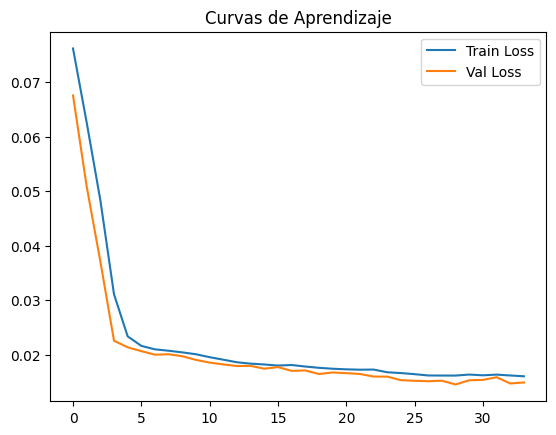

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step


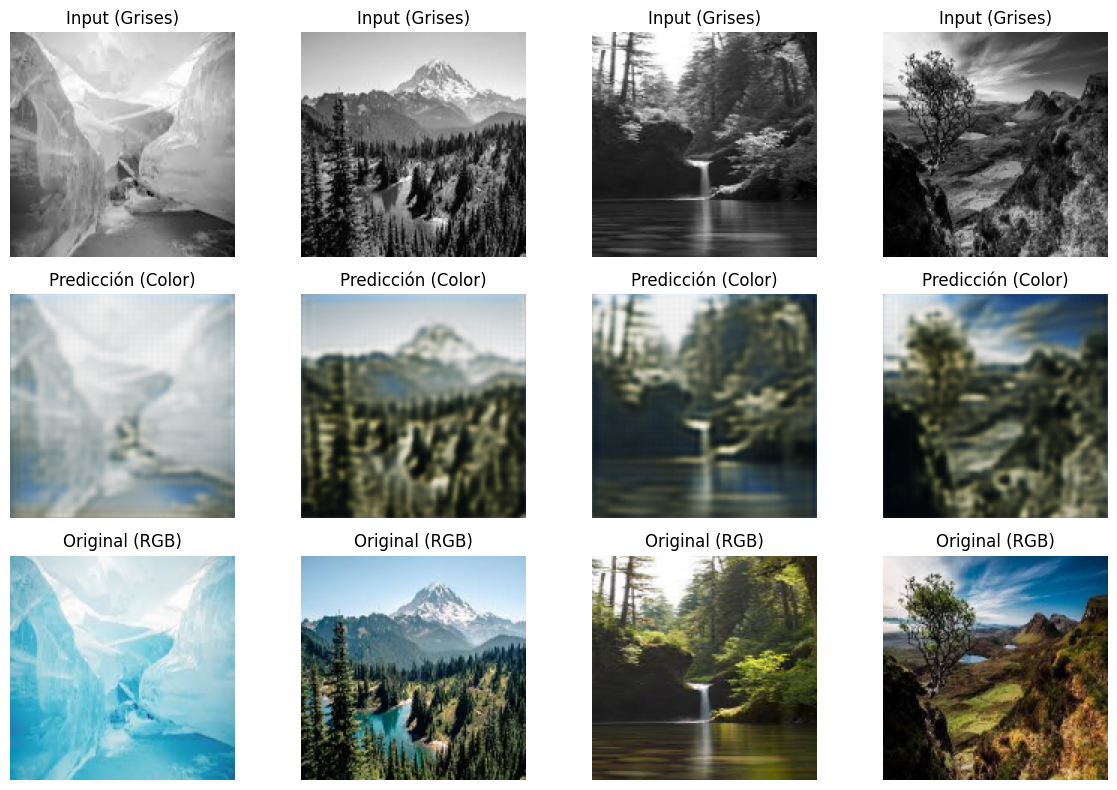

In [67]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Curvas de Aprendizaje')
plt.legend()
plt.show()

def plot_predictions(model, x_test, y_test, n=4):
    preds = model.predict(x_test[:n])
    plt.figure(figsize=(12, 8))

    for i in range(n):
        # Original Gris
        ax = plt.subplot(3, n, i + 1)
        plt.imshow(x_test[i].reshape(150, 150), cmap='gray')
        plt.title("Input (Grises)")
        plt.axis("off")

        # Predicción IA
        ax = plt.subplot(3, n, i + 1 + n)
        plt.imshow(preds[i])
        plt.title("Predicción (Color)")
        plt.axis("off")

        # Ground Truth
        ax = plt.subplot(3, n, i + 1 + 2*n)
        plt.imshow(y_test[i])
        plt.title("Original (RGB)")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_predictions(autoencoder, X_test, Y_test)